In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

# 1. Problem Statement

In [42]:
Prediction of Estimated deliveries using historical data.

SyntaxError: invalid syntax. Perhaps you forgot a comma? (312716454.py, line 1)

# 2. Data Collection

In [43]:
df=pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


# 3. Data Preprocessing

In [44]:
# Checking Null values

df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [45]:
#Observation : No null values in the dataset

In [46]:
# Checking duplicate values
df.duplicated().sum()


0

In [47]:
#Observation : No duplicate values in the dataset

In [48]:
# Checking data type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [49]:
# Columns - Region , Model , Source_Type are categorical

In [50]:
categorical_cols = ["Region", "Model", "Source_Type"]

df = pd.get_dummies(df,columns=categorical_cols,drop_first=True)
                    

# 4. EDA

## Dataset rows & columns

In [51]:
df.shape

(2640, 18)

## Statistical Information 

In [52]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712,0.250000,0.250000,0.250000,0.200000,0.200000,0.200000,0.200000,0.334848,0.334848
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883,0.433095,0.433095,0.433095,0.400076,0.400076,0.400076,0.400076,0.472027,0.472027
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000,0.250000,0.250000,0.250000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Distribution of target variable (Estimated Deliveries)

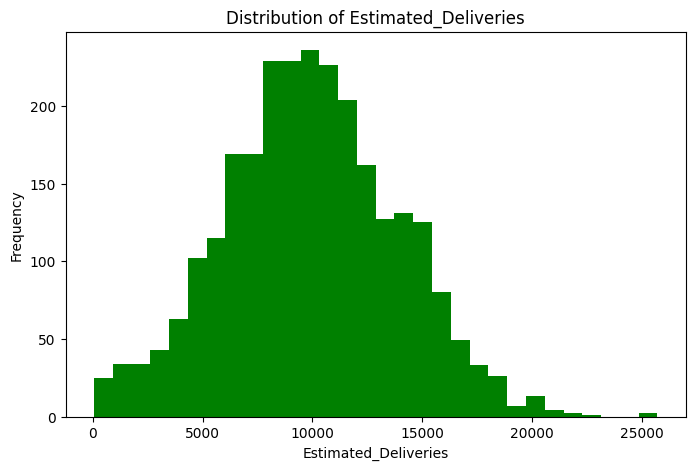

In [53]:
plt.figure(figsize=(8,5))
plt.title('Distribution of Estimated_Deliveries')
plt.hist(df["Estimated_Deliveries"],bins=30,color='green')
plt.xlabel('Estimated_Deliveries')
plt.ylabel('Frequency')
plt.show()

## Box Plot

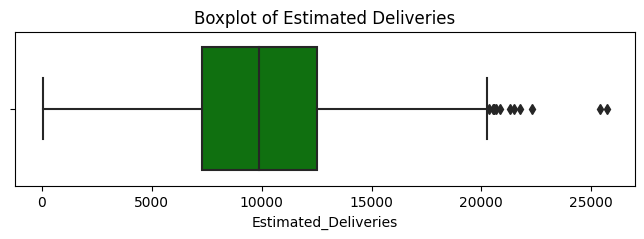

In [54]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df["Estimated_Deliveries"], color="green")
plt.title("Boxplot of Estimated Deliveries")
plt.show()

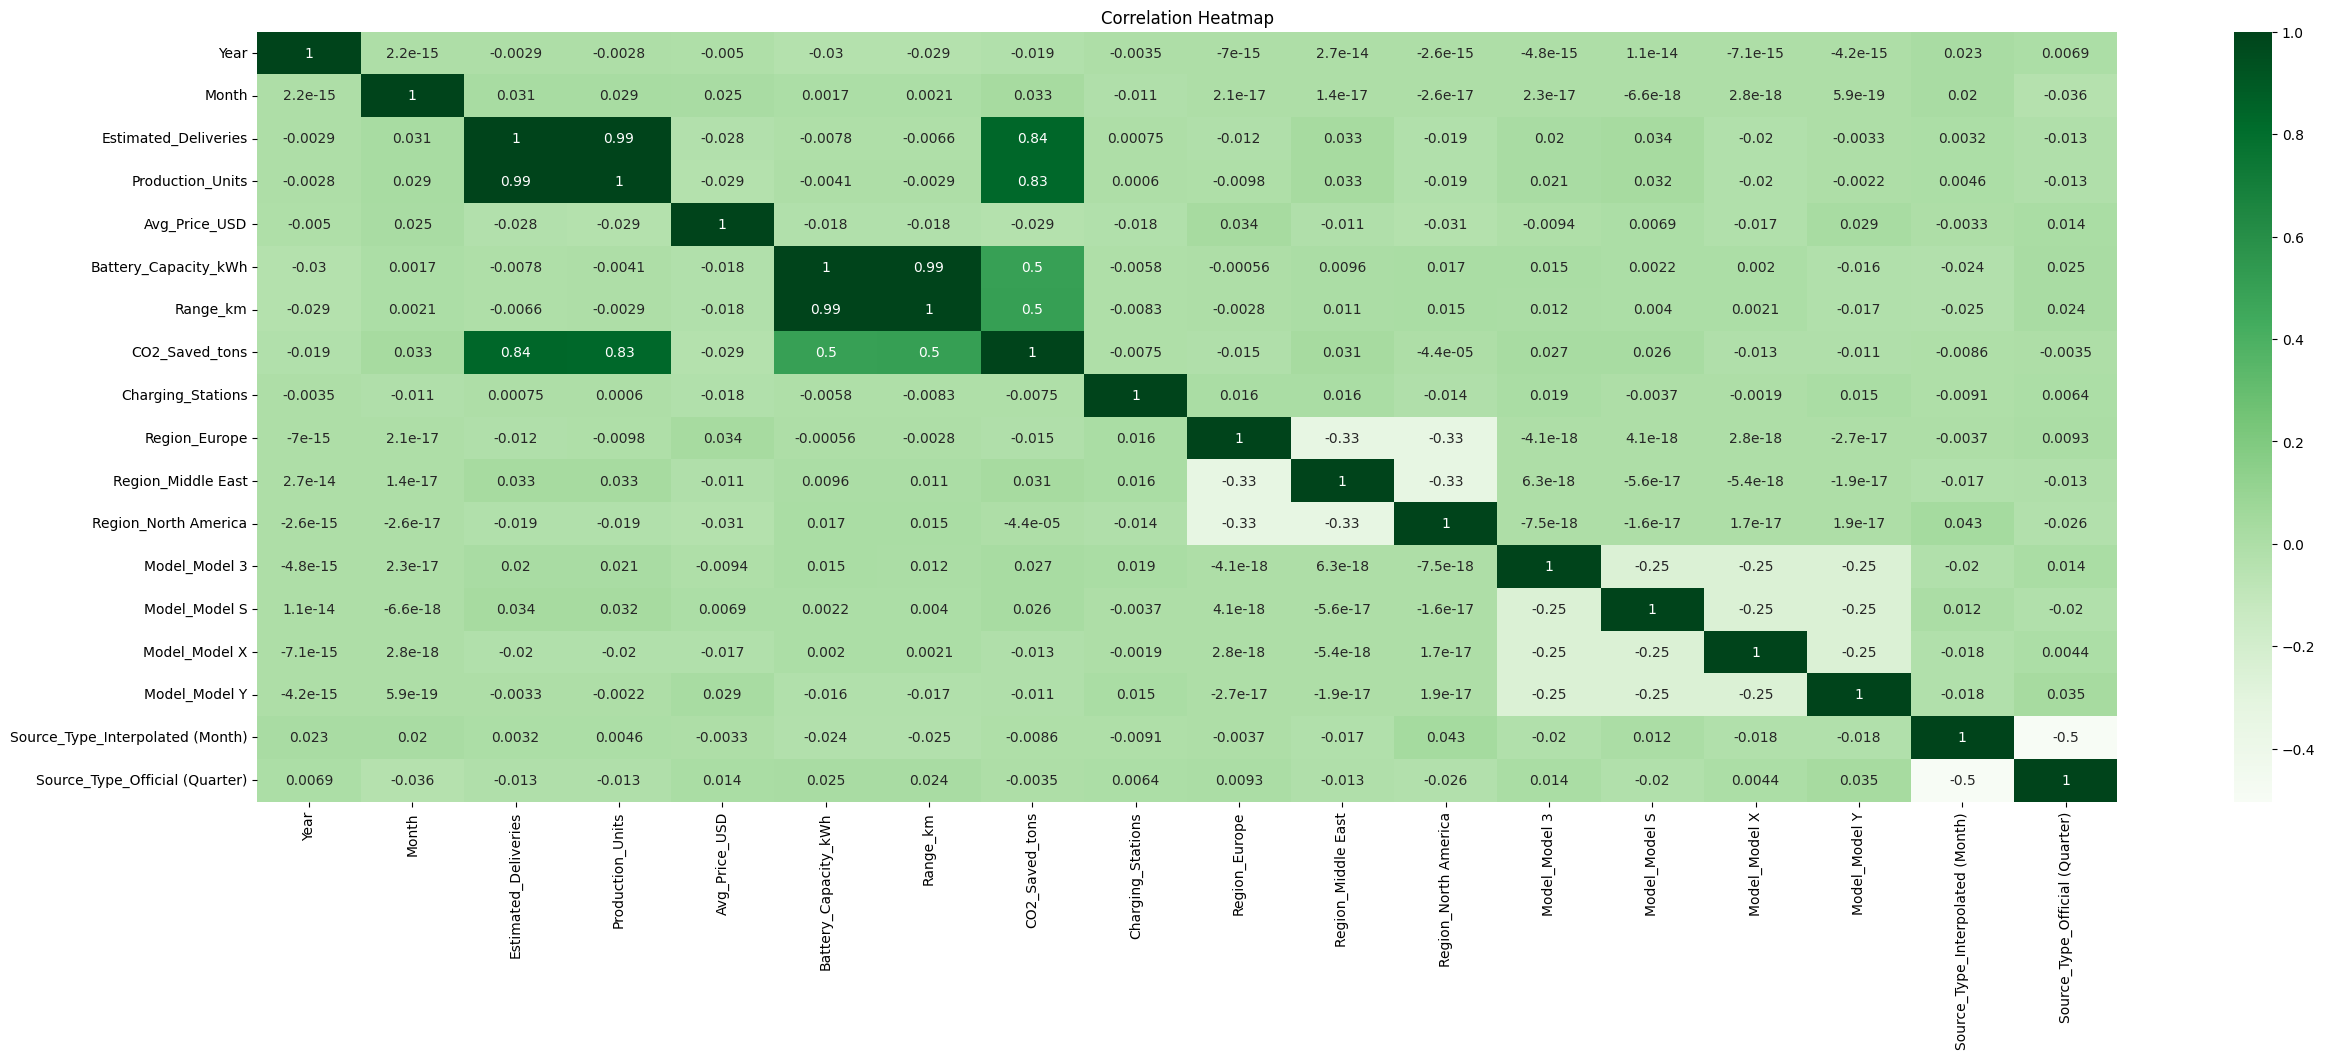

In [55]:
plt.figure(figsize=(30,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,cmap="Greens",annot=True)         
plt.title("Correlation Heatmap")
plt.show()

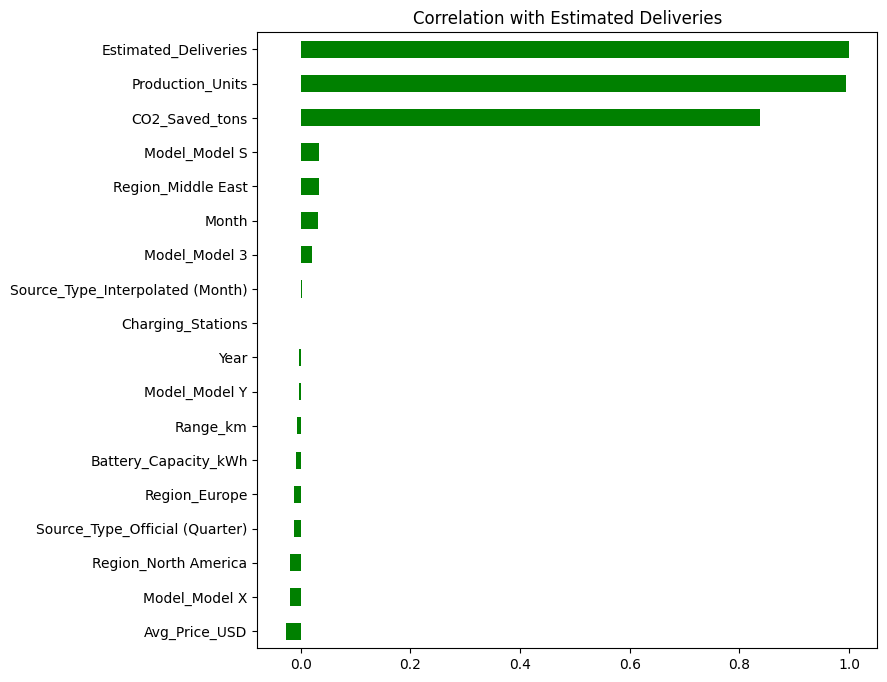

In [56]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,8))
corr["Estimated_Deliveries"].sort_values().plot(kind="barh",color="green")
plt.title("Correlation with Estimated Deliveries")
plt.show()

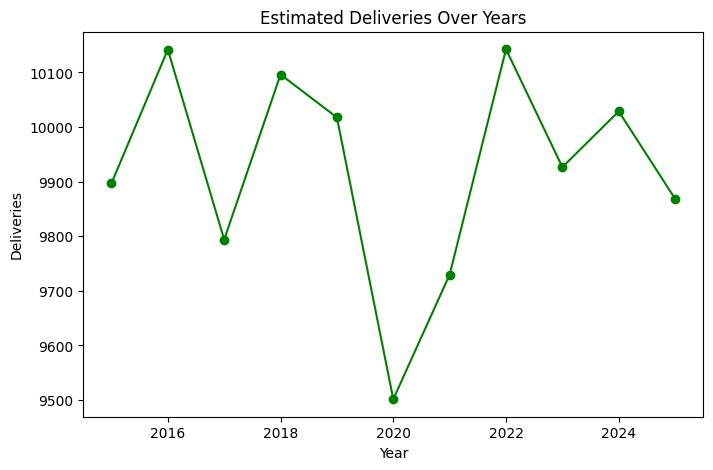

In [57]:
year_price = df.groupby("Year")["Estimated_Deliveries"].mean()

plt.figure(figsize=(8,5))
plt.plot(year_price.index, year_price.values, marker='o',color="green")
plt.title("Estimated Deliveries Over Years")
plt.xlabel("Year")
plt.ylabel("Deliveries")
plt.show()

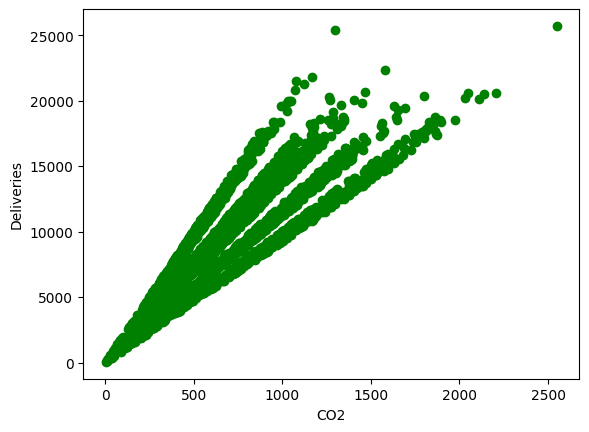

In [58]:
plt.scatter(df["CO2_Saved_tons"], df["Estimated_Deliveries"],color="green")
plt.xlabel("CO2")
plt.ylabel("Deliveries")
plt.show()

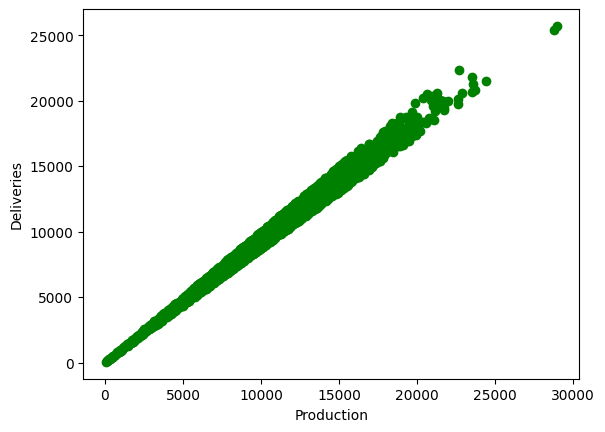

In [59]:
plt.scatter(df["Production_Units"], df["Estimated_Deliveries"],color="green")
plt.xlabel("Production")
plt.ylabel("Deliveries")
plt.show()

# 5. Feature Engineering

In [60]:
X = df.drop("Estimated_Deliveries", axis=1)

y = df["Estimated_Deliveries"]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 6.Model Building

## Linear Regression 

In [62]:
linear_model=LinearRegression()
linear_model.fit(X_train,y_train)

y_pred = linear_model.predict(X_test)

# Model Evalution

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 309.7036740991363
MSE : 147478.3613769849
RMSE : 384.02911527250757
R2 Score : 0.990106298761102


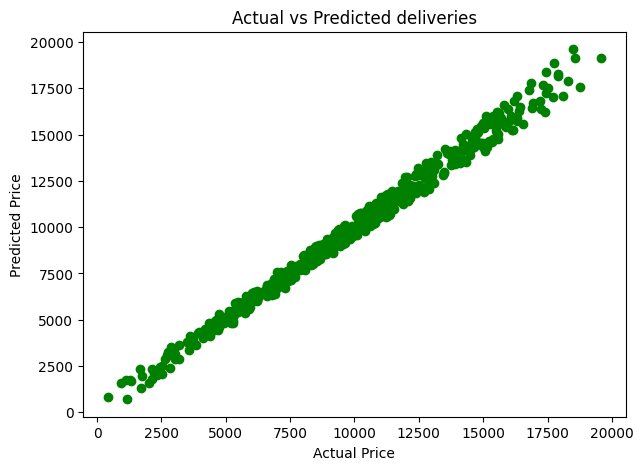

In [63]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred,color="green")

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted deliveries")

plt.show()

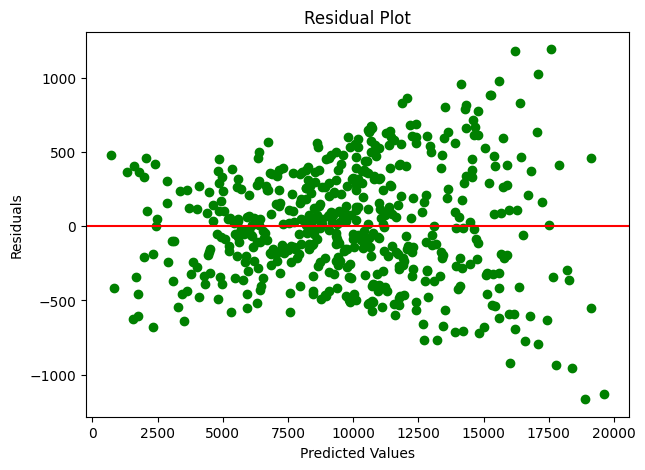

In [64]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals,color="green")

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

## Decision Tree Model

In [65]:
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)


mae = mean_absolute_error(y_test, y_pred_dt)

mse = mean_squared_error(y_test, y_pred_dt)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_dt)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)





MAE : 399.7462121212121
MSE : 299319.0984848485
RMSE : 547.1006292126235
R2 Score : 0.9799199441338008


## Random Forest Model

In [66]:
rf=RandomForestRegressor(random_state=42,n_estimators=200)
rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)

mse = mean_squared_error(y_test, y_pred_rf)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_rf)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)





MAE : 320.64185606060613
MSE : 164214.9751833333
RMSE : 405.23446939189824
R2 Score : 0.9889835099315764


## 8. Model Comparison

In [67]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],

    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],

    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred_dt),
        mean_squared_error(y_test, y_pred_rf)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],

    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

comparison = comparison.sort_values(by="R2 Score", ascending=False)

print(comparison)

               Model         MAE            MSE        RMSE  R2 Score
0  Linear Regression  309.703674  147478.361377  384.029115  0.990106
2      Random Forest  320.641856  164214.975183  405.234469  0.988984
1      Decision Tree  399.746212  299319.098485  547.100629  0.979920


# Hyperparameter Tunning

In [68]:
params = {"n_estimators": [100, 200],"max_depth": [5, 10, None],"min_samples_split": [2, 5]}

grid = GridSearchCV(RandomForestRegressor(random_state=42),param_grid=params,cv=5,scoring="r2")

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [69]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))

R2: 0.9889835099315764
RMSE: 405.23446939189824


In [70]:
best_model = comparison.iloc[0]


print("Best Performing Model")
print(f"Model      : {best_model['Model']}")
print(f"R2 Score   : {best_model['R2 Score']:.4f}")
print(f"RMSE       : {best_model['RMSE']:.4f}")


Best Performing Model
Model      : Linear Regression
R2 Score   : 0.9901
RMSE       : 384.0291


# Second Model Building

In [79]:
X = df.drop(["Estimated_Deliveries", "Production_Units"], axis=1)
y = df["Estimated_Deliveries"]

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Linear Regression 

In [81]:
linear_model=LinearRegression()
linear_model.fit(X_train,y_train)

y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 658.4879434590391
MSE : 869197.1469144605
RMSE : 932.3074315452283
R2 Score : 0.9416892294640303


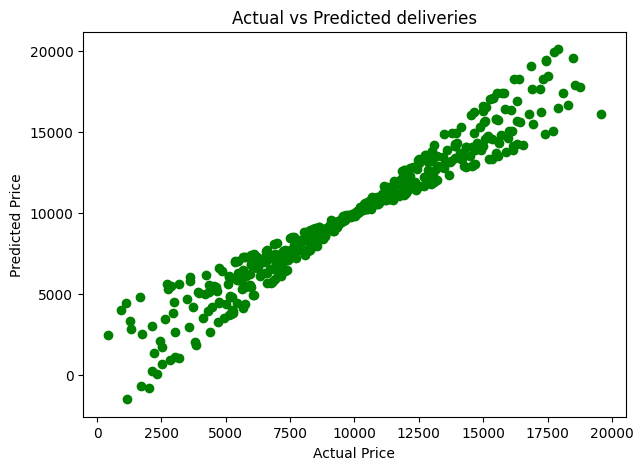

In [82]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred , color="green")

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted deliveries")

plt.show()

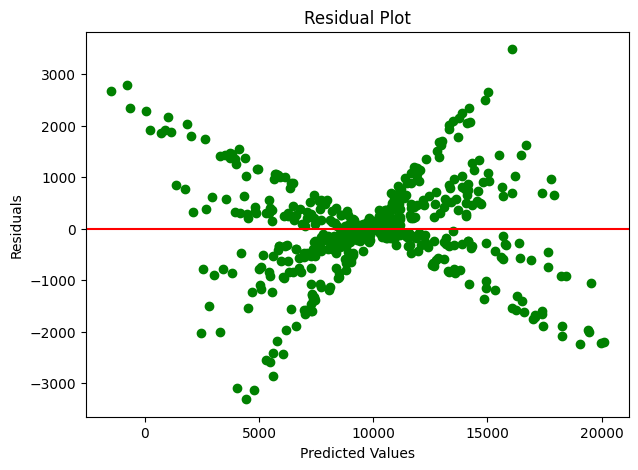

In [83]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))

plt.scatter(y_pred, residuals,color="green")

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

## Decision Tree Model

In [84]:
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)


mae = mean_absolute_error(y_test, y_pred_dt)

mse = mean_squared_error(y_test, y_pred_dt)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_dt)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)





MAE : 225.46401515151516
MSE : 120612.82386363637
RMSE : 347.29357014439006
R2 Score : 0.9919085943609293


## Random Forest model

In [85]:
rf=RandomForestRegressor(random_state=42,n_estimators=200)
rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)

mse = mean_squared_error(y_test, y_pred_rf)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_rf)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)





MAE : 115.46845643939395
MSE : 27171.5546107481
RMSE : 164.83796471307238
R2 Score : 0.9981771750038098


## Model Comparison

In [86]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],

    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ],

    "MSE": [
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, y_pred_dt),
        mean_squared_error(y_test, y_pred_rf)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],

    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ]
})

comparison = comparison.sort_values(by="R2 Score", ascending=False)

print(comparison)

               Model         MAE            MSE        RMSE  R2 Score
2      Random Forest  115.468456   27171.554611  164.837965  0.998177
1      Decision Tree  225.464015  120612.823864  347.293570  0.991909
0  Linear Regression  658.487943  869197.146914  932.307432  0.941689


In [87]:
best_model = comparison.iloc[0]


print("Best Performing Model")
print(f"Model      : {best_model['Model']}")
print(f"R2 Score   : {best_model['R2 Score']:.4f}")
print(f"RMSE       : {best_model['RMSE']:.4f}")


Best Performing Model
Model      : Random Forest
R2 Score   : 0.9982
RMSE       : 164.8380


# 9. Conclusion : Regression Models

# 10. Time Series Forecasting

## Create a Date column

In [ ]:
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str))

## Sort

In [ ]:
df = df.sort_values("Date")
df

## Aggregate monthly deliveries

In [ ]:
ts = df.groupby("Date")["Estimated_Deliveries"].sum()
ts

## Plot the time series

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(ts)
plt.title("Tesla Monthly Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.show()

## Train-Test Split

In [ ]:
train = ts[:-12]
test = ts[-12:]

In [ ]:
pip install statsmodels

## Applying ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(9,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=12)
print(forecast)

## Evalute

In [ ]:
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE :", mae)
print("RMSE:", rmse)

## ADF Test

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

## Trying different ARIMA orders

In [ ]:
orders = [
    (1,1,1),
    (2,1,2),
    (3,1,1),
    (5,1,2),
    (2,0,2),
    (1,0,1)
]

for order in orders:
    model = ARIMA(train, order=order)
    fitted = model.fit()

    pred = fitted.forecast(steps=len(test))

    mae = mean_absolute_error(test, pred)

    print(order, "MAE =", round(mae,2))

## Applying values with lowest MAE

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,0,1))
model_fit = model.fit()

forecast = model_fit.forecast(steps=12)
print(forecast)

# Plot

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("Tesla Deliveries Forecast")
plt.show()

# Conclusion